In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("BostonHousing.csv")

In [3]:
df

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [4]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [5]:
df.columns

Index(['Crime_rate', 'zn', 'indus', 'chas', 'nox', 'rm', 'Age', 'Distance',
       'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [6]:
df.dtypes

Crime_rate    float64
zn            float64
indus         float64
chas            int64
nox           float64
rm            float64
Age           float64
Distance      float64
rad             int64
tax             int64
ptratio       float64
b             float64
lstat         float64
medv          float64
dtype: object

In [7]:
df['rm'] = df['rm'].fillna(df['rm'].median())

In [8]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [10]:
numeric_cols = df.select_dtypes(include = [np.number]).columns.tolist()

In [11]:
numeric_cols

['Crime_rate',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'Age',
 'Distance',
 'rad',
 'tax',
 'ptratio',
 'b',
 'lstat',
 'medv']

In [12]:
outlier_summary = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1

    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    column_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(column_outliers)
    
print("--- Outlier Count per Column ---")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

--- Outlier Count per Column ---
Crime_rate: 66
zn: 68
indus: 0
chas: 35
nox: 0
rm: 30
Age: 0
Distance: 5
rad: 0
tax: 0
ptratio: 15
b: 77
lstat: 7
medv: 40


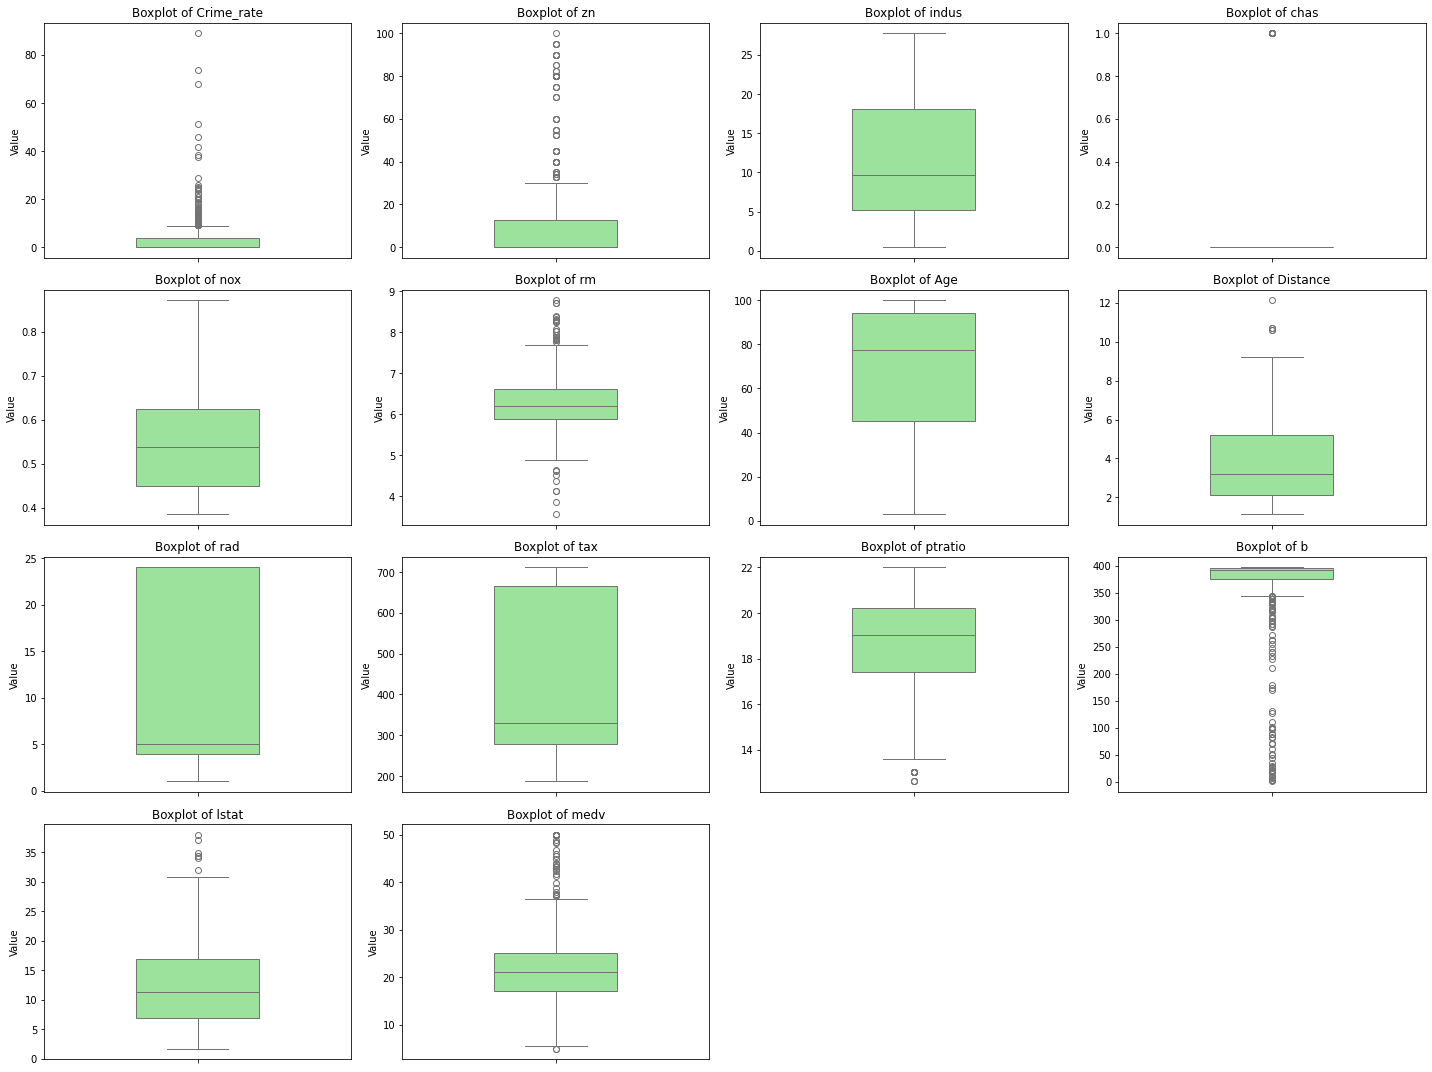

In [13]:
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='lightgreen', width=0.4)
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [14]:
df_capped = df.copy()

for col in numeric_cols:
    q1 = df_capped[col].quantile(0.25)
    q3 = df_capped[col].quantile(0.75)
    IQR = q3 - q1
    
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    
    df_capped[col] = np.clip(df_capped[col], lower_bound, upper_bound)

print("Capping complete.")

Capping complete.


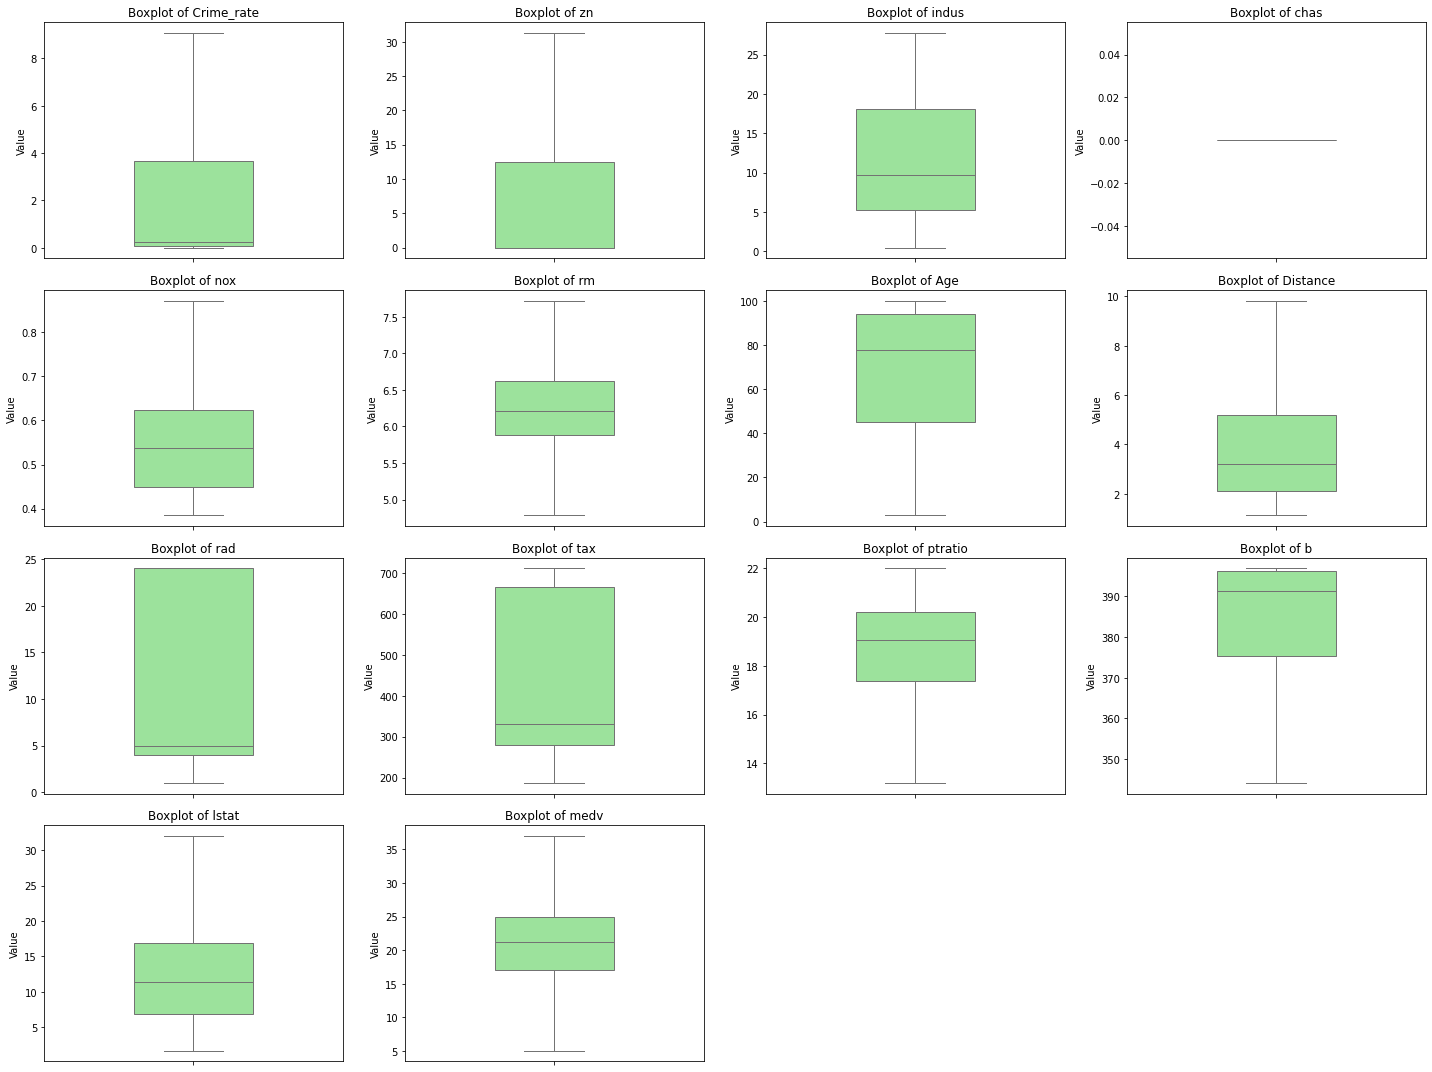

In [15]:
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_capped[col], color='lightgreen', width=0.4)
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [17]:
X = df_capped.drop('medv', axis=1)
y = df_capped['medv']

X_train, X_test,  y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"Training set size: {X_train.shape}") 
print(f"Training labels size: {y_train.shape}") 
print(f"Testing set size: {X_test.shape}")   J

Training set size: (404, 13)
Training labels size: (404,)
Testing set size: (102, 13)


In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [19]:
print(f"Intercept: {model.intercept_}")
coeff_df = pd.DataFrame(model.coef_, X.columns, columns = ['Coefficient'])
print(coeff_df)

Intercept: 27.4892410372344
             Coefficient
Crime_rate -6.550695e-01
zn          3.110715e-02
indus       2.098586e-03
chas       -8.298917e-15
nox        -1.178294e+01
rm          3.462616e+00
Age        -1.352316e-02
Distance   -1.131909e+00
rad         3.145939e-01
tax        -8.851671e-03
ptratio    -8.217656e-01
b           1.874972e-02
lstat      -4.570823e-01


In [20]:
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R-squared:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 2.423238989516427
Mean Squared Error (MSE): 12.092937228730921
Root Mean Squared Error (RMSE): 3.4774900760075393
R-squared: 0.7528267842076606


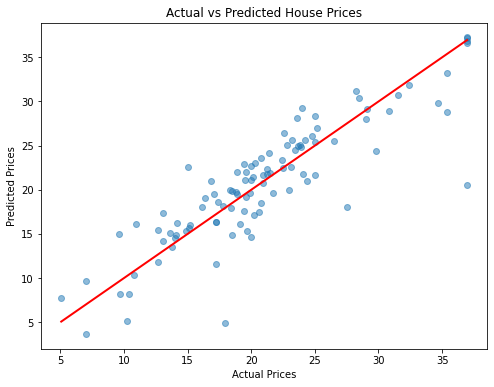

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

***Using Gradient Descent Formula***

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
y_train_arr = y_train.values

In [26]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    f_wb = np.dot(X, w) + b
    error = f_wb - y
    cost = (1/(2*m))*np.sum(np.square(error))
    return cost

def compute_gradient(X, y, w, b):
    m, n = X.shape
    f_wb = np.dot(X, w) + b
    error = f_wb - y
    dj_dw = (1 / m) * np.dot(X.T, error)
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db

def gradient_descent(X, y, w_in, b_in, alpha, iterations):
    w = w_in
    b = b_in
    cost_history = []
    for i in range (iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i:4}: Cost {cost_history[-1]:8.2f}")
    return w, b, cost_history

In [27]:
initial_w = np.zeros(X_train_scaled.shape[1])
initial_b = 0.0

iterations = 1000
learning_rate = 0.1

w_final, b_final, cost_history = gradient_descent(X_train_scaled, y_train_arr, initial_w, initial_b, learning_rate, iterations)

print(f"\nTraining complete!")
print(f"Final b: {b_final}")
print(f"Final w's: {w_final}")

Iteration    0: Cost   214.09
Iteration  100: Cost     6.45
Iteration  200: Cost     6.37
Iteration  300: Cost     6.34
Iteration  400: Cost     6.33
Iteration  500: Cost     6.33
Iteration  600: Cost     6.32
Iteration  700: Cost     6.32
Iteration  800: Cost     6.32
Iteration  900: Cost     6.32

Training complete!
Final b: 22.116646039603946
Final w's: [-2.14352092  0.37890832  0.0118073   0.         -1.38464506  2.19187817
 -0.37834227 -2.37305765  2.67904605 -1.45961504 -1.80822195  0.3578317
 -3.20186532]


In [28]:
y_pred_gd = np.dot(X_test_scaled, w_final) + b_final

print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred_gd))
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred_gd))
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred_gd)))
print('R-squared:', metrics.r2_score(y_test, y_pred_gd))

Mean Absolute Error (MAE): 2.423573289381593
Mean Squared Error (MSE): 12.097943802142368
Root Mean Squared Error (RMSE): 3.478209855966481
R-squared: 0.7527244525055438


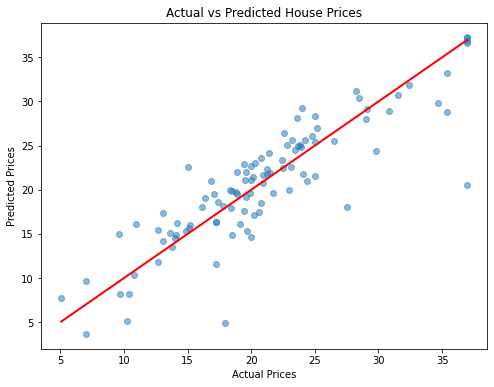

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gd, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()